In [9]:
!pip install seaborn pandas matplotlib scikit-learn numpy pillow
# Import all needed libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
# Setting global style for professional plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 16})

In [3]:
def load_and_preprocess(image_path):
    """
    Loads an image and converts it to a grayscale matrix.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at: {image_path}")

    # Convert to Grayscale (L mode) -> Matrix A (Height x Width)
    img_obj = Image.open(image_path).convert('L')
    img_matrix = np.array(img_obj)
    
    print(f"✅ Image Loaded Successfully.")
    print(f"   Dimensions: {img_matrix.shape[1]}x{img_matrix.shape[0]} pixels")
    print(f"   Rank (Full): {min(img_matrix.shape)}")
    
    return img_matrix

In [4]:
def perform_svd(matrix):
    """
    Decomposes matrix A into U, S, Vt using efficient Linear Algebra libraries.
    A = U * diag(S) * Vt
    """
    print("⚙️ Computing SVD (Standard Algorithm)...")
    # full_matrices=False ensures we get the economic SVD (compact form)
    U, S, Vt = np.linalg.svd(matrix, full_matrices=False)
    print("✅ Decomposition Complete.")
    return U, S, Vt

In [5]:
def plot_singular_spectrum(S, img_shape):
    """
    Visualizes the mathematical properties of the decomposition:
    1. Singular Values decay (Log scale).
    2. Cumulative Energy (Information Retention).
    """
    # Calculate Energy (squared singular values)
    energy = S ** 2
    total_energy = np.sum(energy)
    cumulative_energy = np.cumsum(energy) / total_energy
    
    # Threshold k for 90% information
    k_90 = np.argmax(cumulative_energy >= 0.90) + 1
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Singular Values (Scree Plot)
    axes[0].semilogy(S, color='#1f77b4', linewidth=2)
    axes[0].set_title('Singular Values Decay (Log Scale)')
    axes[0].set_xlabel('k (Component Index)')
    axes[0].set_ylabel(r'Singular Value $\sigma_k$')
    axes[0].grid(True, which="both", ls="-", alpha=0.3)
    
    # Plot 2: Cumulative Energy
    axes[1].plot(cumulative_energy, color='#d62728', linewidth=2)
    axes[1].axvline(k_90, color='black', linestyle='--', label=f'90% Info at k={k_90}')
    axes[1].axhline(0.90, color='black', linestyle=':', alpha=0.5)
    
    axes[1].set_title('Cumulative Energy (Information Retention)')
    axes[1].set_xlabel('k (Number of Components)')
    axes[1].set_ylabel('Percentage of Variance Explained')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle(f"Spectral Analysis of {img_shape[1]}x{img_shape[0]} Matrix", y=1.05)
    plt.tight_layout()
    plt.show()
    
    return k_90

In [6]:
def analyze_compression(matrix, U, S, Vt, k_values):
    """
    Reconstructs the image at various k levels and computes rigorous metrics.
    """
    h, w = matrix.shape
    original_size = h * w  # Size if storing raw pixels
    
    results = []
    
    # Setup visualization
    cols = len(k_values) + 1
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 5))
    
    # Plot Original
    axes[0].imshow(matrix, cmap='gray')
    axes[0].set_title("Original Image\n(Ground Truth)")
    axes[0].axis('off')
    
    print("\n--- RECONSTRUCTION & METRICS ---")
    
    for idx, k in enumerate(k_values):
        # 1. Low-rank Approximation (Math: A_k = U_k * S_k * Vt_k)
        U_k = U[:, :k]
        S_k = np.diag(S[:k])
        Vt_k = Vt[:k, :]
        reconstructed = U_k @ S_k @ Vt_k
        
        # 2. Error Calculation (Frobenius Norm)
        # ||A - A_k||_F / ||A||_F
        error_norm = np.linalg.norm(matrix - reconstructed)
        original_norm = np.linalg.norm(matrix)
        relative_error = error_norm / original_norm
        fidelity = (1 - relative_error) * 100
        
        # 3. Memory Compression Analysis
        # Compressed: k vectors of size h, k vectors of size w, k singular values
        compressed_size = k * (h + w + 1) 
        compression_ratio = original_size / compressed_size
        
        # Append stats
        results.append({
            "k (Rank)": k,
            "Storage (Elements)": f"{compressed_size:,}",
            "Compression Ratio": f"{compression_ratio:.1f}x",
            "Fidelity (1-Err)": f"{fidelity:.2f}%",
            "Visual Quality": "Excellent" if fidelity > 90 else ("Good" if fidelity > 80 else "Poor")
        })
        
        # 4. Visualization
        ax = axes[idx + 1]
        ax.imshow(reconstructed, cmap='gray')
        ax.set_title(f"Rank k={k}\nRatio: {compression_ratio:.1f}x")
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

### For SVD, we focus on grayscale to simplify the mathematical matrix operations.

✅ Image Loaded Successfully.
   Dimensions: 394x590 pixels
   Rank (Full): 394
⚙️ Computing SVD (Standard Algorithm)...
✅ Decomposition Complete.


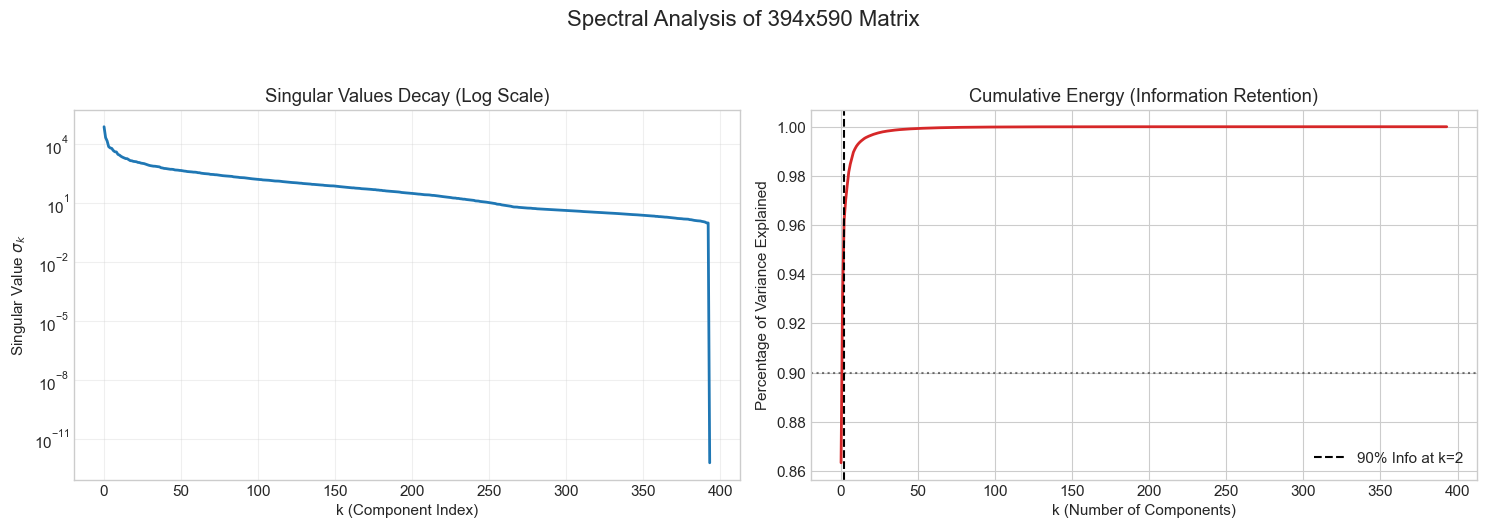

💡 Analytical Insight: To retain 90% of the image information, k=2 is the optimal choice.


--- RECONSTRUCTION & METRICS ---


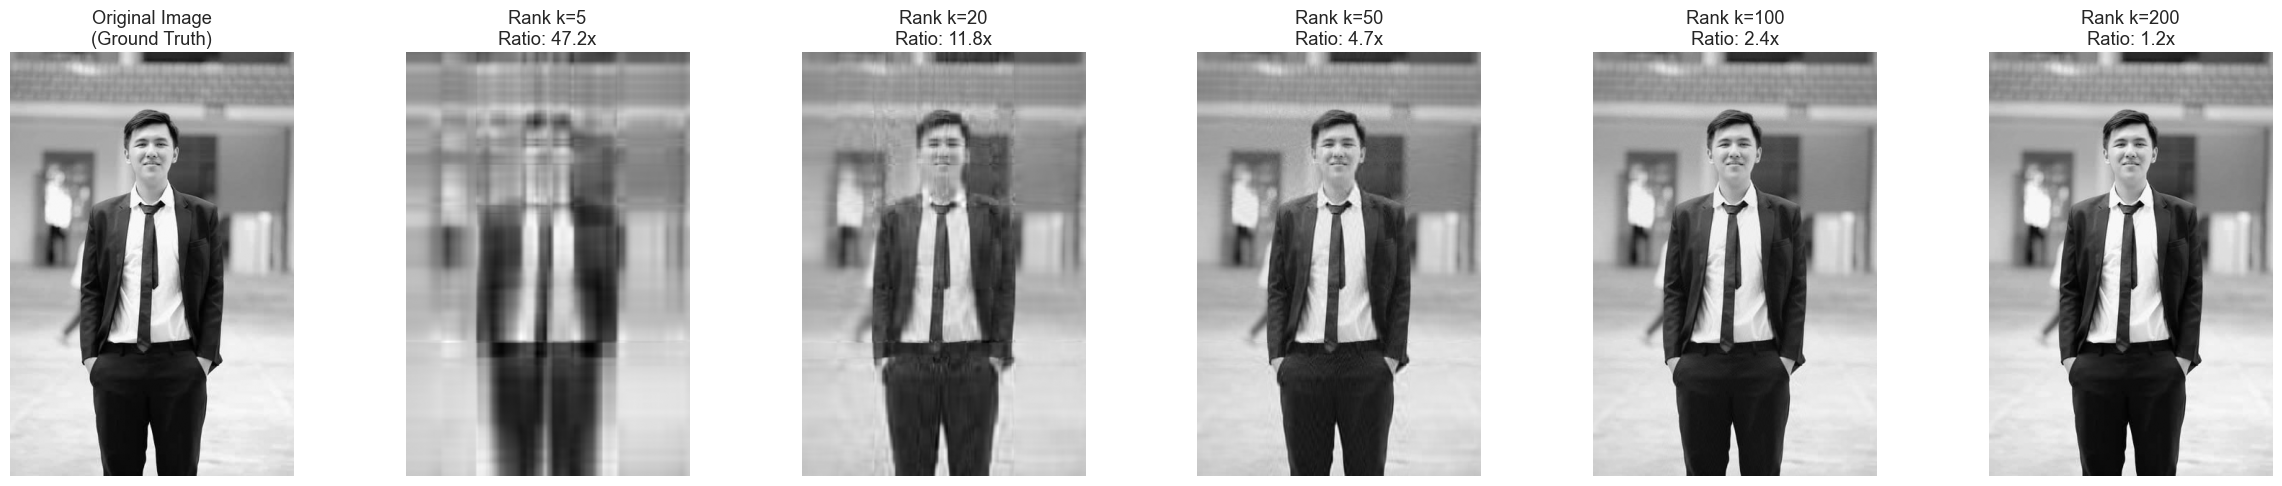


=== FINAL PERFORMANCE REPORT ===


,k (Rank),Storage (Elements),Compression Ratio,Fidelity (1-Err),Visual Quality
0,5,"4,925",47.2x,84.57%,Good
1,20,"19,700",11.8x,94.02%,Excellent
2,50,"49,250",4.7x,97.28%,Excellent
3,100,"98,500",2.4x,98.92%,Excellent
4,200,"197,000",1.2x,99.81%,Excellent


SVD demonstrates that the image energy is primarily concentrated in the leading singular values.A rank of k=50 is sufficient to reconstruct a high-fidelity image with minimal visual loss.


In [ ]:
IMAGE_PATH = "./tien.jpg"  # Ensure this file exists
K_LEVELS = [5, 20, 50, 100, 200]  # Standard benchmarks
try:
    # 1. Process
    img_matrix = load_and_preprocess(IMAGE_PATH)
    U, S, Vt = perform_svd(img_matrix)
    
    # 2. Analyze Spectrum
    optimal_k = plot_singular_spectrum(S, img_matrix.shape)
    print(f"💡 Analytical Insight: To retain 90% of the image information, k={optimal_k} is the optimal choice.\n")
    
    # 3. Evaluate Reconstruction
    df_results = analyze_compression(img_matrix, U, S, Vt, K_LEVELS)
    
    # 4. Final Report Table
    print("\n=== FINAL PERFORMANCE REPORT ===")
    display(df_results) # Works in Jupyter/Colab
    
    print("SVD demonstrates that the image energy is primarily concentrated in the leading singular values." \
    " A rank of k=50 is sufficient to reconstruct a high-fidelity image with minimal visual loss.")
except Exception as e:
    print(f"❌ Error occurred: {e}")